Performance Analytics

Day 4 - Mutual Fund Analytics

This notebook contains:
- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")
scheme = pd.read_csv("../data/processed/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [8]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [9]:
scheme.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'anomaly'],
      dtype='str')

In [10]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

In [ ]:
nav = nav.sort_values(["amfi_code","date"])

In [13]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [14]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


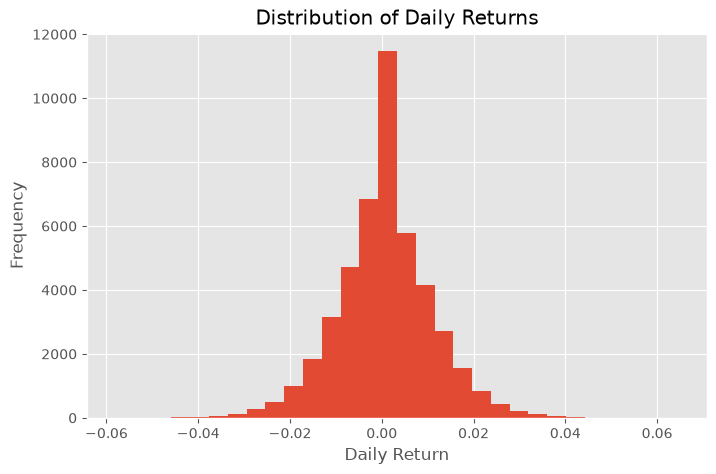

In [15]:
plt.figure(figsize=(8,5))
plt.hist(nav["daily_return"].dropna(), bins=30)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [17]:
scheme[[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]].head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [21]:
nav["date"].min()


Timestamp('2022-01-03 00:00:00')

In [22]:
nav["date"].max()

Timestamp('2026-05-29 00:00:00')

In [23]:
latest_date = nav["date"].max()

In [24]:
def calculate_cagr(nav_data, years):
    start_date = latest_date - pd.DateOffset(years=years)

    filtered = nav_data[nav_data["date"] >= start_date]

    cagr = filtered.groupby("amfi_code").agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )

    cagr[f"CAGR_{years}Y"] = (
        (cagr["end_nav"] / cagr["start_nav"]) ** (1 / years) - 1
    ) * 100

    return cagr[[f"CAGR_{years}Y"]]

In [25]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [26]:
cagr_table = cagr_1.join(cagr_3).join(cagr_5).reset_index()

In [27]:
cagr_table = cagr_table.merge(
    scheme[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

In [28]:
cagr_table = cagr_table[
    ["scheme_name", "CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]
]

cagr_table.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [29]:
cagr_table.to_csv("../reports/cagr_comparison.csv", index=False)

In [30]:
rf = 0.065

In [33]:
mean_return = nav.groupby("amfi_code")["daily_return"].mean()
mean_return.head()

amfi_code
100016    0.000142
100025    0.000170
100033    0.001080
101206    0.000852
101207    0.000424
Name: daily_return, dtype: float64

In [34]:
std_return =nav.groupby("amfi_code")["daily_return"].std()
std_return.head()

amfi_code
100016    0.009164
100025    0.002460
100033    0.011929
101206    0.009177
101207    0.016251
Name: daily_return, dtype: float64

In [35]:
sharpe_ratio = ((mean_return * 252)- rf) / (std_return * np.sqrt(252))

In [36]:
sharpe_table = sharpe_ratio.reset_index()
sharpe_table.columns = ["amfi_code", "Sharpe_Ratio"]

sharpe_table = sharpe_table.merge(
    scheme[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_table = sharpe_table[["scheme_name", "Sharpe_Ratio"]]

In [37]:
sharpe_table["Rank"] = sharpe_table["Sharpe_Ratio"].rank(
    ascending=False,
    method="dense"
)

sharpe_table = sharpe_table.sort_values("Rank")

sharpe_table.head(10)

,scheme_name,Sharpe_Ratio,Rank
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1.0
30,Kotak Flexicap Fund - Regular - Growth,1.306744,2.0
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3.0
19,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4.0
25,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5.0
38,DSP Midcap Fund - Regular - Growth,1.132122,6.0
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,7.0
9,Nippon India Large Cap Fund - Regular - Growth,1.081659,8.0
3,ABSL Frontline Equity Fund - Regular - Growth,1.027213,9.0
24,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,10.0


In [38]:
sharpe_table.to_csv("../reports/sharpe_ratio.csv", index=False)

In [39]:
downside = nav.copy()

downside["downside_return"] = downside["daily_return"]

downside.loc[
    downside["downside_return"] > 0,
    "downside_return"
] = 0

downside.head()

,amfi_code,date,nav,daily_return,downside_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,0.000000
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [40]:
downside_std = downside.groupby("amfi_code")["downside_return"].std()
downside_std.head()

amfi_code
100016    0.005163
100025    0.001382
100033    0.006632
101206    0.004989
101207    0.009256
Name: downside_return, dtype: float64

In [42]:
sortino_ratio = ((mean_return * 252) - rf) / (downside_std * np.sqrt(252))

sortino_ratio.head()

amfi_code
100016   -0.357702
100025   -1.009643
100033    1.967316
101206    1.889576
101207    0.285576
dtype: float64

In [43]:
sortino_table = sortino_ratio.reset_index()
sortino_table.columns = ["amfi_code", "Sortino_Ratio"]

sortino_table = sortino_table.merge(
    scheme[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_table = sortino_table[["scheme_name", "Sortino_Ratio"]]

In [44]:
sortino_table["Rank"] = sortino_table["Sortino_Ratio"].rank(
    ascending=False,
    method="dense"
)

sortino_table = sortino_table.sort_values("Rank")

sortino_table.head(10)

,scheme_name,Sortino_Ratio,Rank
34,Mirae Asset Large Cap Fund - Regular - Growth,2.609850,1.0
30,Kotak Flexicap Fund - Regular - Growth,2.463887,2.0
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.278106,3.0
19,SBI Bluechip Fund - Regular Plan - Growth,2.243325,4.0
25,ICICI Pru Midcap Fund - Regular - Growth,2.158384,5.0
38,DSP Midcap Fund - Regular - Growth,2.011887,6.0
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.967316,7.0
9,Nippon India Large Cap Fund - Regular - Growth,1.961986,8.0
3,ABSL Frontline Equity Fund - Regular - Growth,1.889576,9.0
24,ICICI Pru Bluechip Fund - Direct - Growth,1.877411,10.0


In [60]:
from scipy.stats import linregress

In [61]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [62]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [67]:
nifty100.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [68]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [69]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [70]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [71]:
nifty100 = nifty100[["date", "benchmark_return"]]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [72]:
nifty100.columns

Index(['date', 'benchmark_return'], dtype='str')